In [34]:
# script to make figure 1 scatterplots and calculate correlations of empirical MPRA to Malinois Predictions
# activity and skew

In [1]:
# import packages
import pandas as pd
import os
from tqdm import tqdm
from scipy import stats
import torch
import matplotlib.pyplot as mpl
import seaborn as sns
import numpy as np
import matplotlib
from collections import Counter

In [2]:
# functions needed to convert raw prediction files to DF for plotting
# only taking the forward strand prediction for comparison to MPRA 
# similarly, only using the variant at position 100 to match MPRA
def splitter (string):
    split = string[1:-1].split(',')
    float_split = [float(i) for i in split]
    return float_split

In [3]:
# define function to convert pt to DF
def pt2df (path2pt, n_preds):
    # Open predictions
    pt = torch.load(path2pt)
    # Open VCF used for generating predictions
    vcf = pt['vcf']
    # Use VCF to generate collapsed IDs chr:pos:ref:alt:INFO
    vcf_ids = [(':').join([i,str(j),k,l]) for i,j,k,l in zip(vcf['chrom'],
                                                             vcf['pos'],
                                                             vcf['ref'],
                                                             vcf['alt'])]
    # Make Dictionary of ID:number (basically index) pairs
    id_dict = dict(zip(vcf_ids, [i for i in range(0,len(vcf_ids))]))
    # Iterate over Dictionary to combine ID from VCF with predictions from Tensor
    df_rows = []
    for i in tqdm(id_dict):
        tmp = []
        # Split ID back into Chrom, Pos, Ref, Alt
        splitted = i.split(':')
        chrom = splitted[0]
        pos = splitted[1]
        ref = splitted[2]
        alt = splitted[3]
        # Make a tmp list for ref/alt each cell type
        # K562
        k562_ref_list = []
        k562_alt_list = []
        # HepG2
        hepg2_ref_list = []
        hepg2_alt_list = []
        # SK-N-SH
        sknsh_ref_list = []
        sknsh_alt_list = []
        # Iterate of each prediction
        for x in range(0, n_preds):
            # Get reference for predictions for fwd and rev strands
            ref_pred = pt['ref'][id_dict.get(i), 0, x]
            #ref_rev_comp = pt['ref'][id_dict.get(i), 1, x]
            # Take average of fwd/rev_comp predictions and add to cell type list
            k562_ref_list.append(ref_pred[0].item())
            hepg2_ref_list.append(ref_pred[1].item())
            sknsh_ref_list.append(ref_pred[2].item())
            # Get alternate predictions for fwd and rev strands
            alt_pred = pt['alt'][id_dict.get(i), 0, x]
            #alt_rev_comp = pt['alt'][id_dict.get(i), 1, x]
            # Take average of fwd/rev_comp predictions and add to cell type list
            k562_alt_list.append(alt_pred[0].item())
            hepg2_alt_list.append(alt_pred[1].item())
            sknsh_alt_list.append(alt_pred[2].item())
        # Subtract alt-ref to get skew
        k562_skew = [j-i for i,j in zip(k562_ref_list, k562_alt_list)]
        hepg2_skew = [j-i for i,j in zip(hepg2_ref_list, hepg2_alt_list)]
        sknsh_skew = [j-i for i,j in zip(sknsh_ref_list, sknsh_alt_list)]
        # Build row as tmp list
        tmp.append(chrom)
        tmp.append(pos)
        tmp.append(ref)
        tmp.append(alt)
        tmp.append(k562_ref_list)
        tmp.append(k562_alt_list)
        tmp.append(hepg2_ref_list)
        tmp.append(hepg2_alt_list)
        tmp.append(sknsh_ref_list)
        tmp.append(sknsh_alt_list)
        tmp.append(k562_skew)
        tmp.append(hepg2_skew)
        tmp.append(sknsh_skew)
        # Append tmp list to "rows" list for formatting to DF
        df_rows.append(tmp)
    col_names = ['chrom',
                 'pos',
                 'ref',
                 'alt',
                 'k562_ref_pred',
                 'k562_alt_pred',
                 'hepg2_ref_pred',
                 'hepg2_alt_pred',
                 'sknsh_ref_pred',
                 'sknsh_alt_pred',
                 'k562_skew_pred',
                 'hepg2_skew_pred',
                 'sknsh_skew_pred']
    df = pd.DataFrame(df_rows, columns=col_names)
    return df

In [4]:
def pt2df_dict (path2pts, n_preds):
    df_dict = {}
    pt_list = [i for i in os.listdir(path2pts) if i.endswith('.pt')]
    for i in pt_list:
        print(i)
        chr_key = i.split('_')[0]
        df_dict.update({chr_key : pt2df(f'{path2pts}/{i}', n_preds)})
    return df_dict

In [5]:
def vep_no_act(df, cell_type):
    ref = []
    alt = []
    skew = []
    for i, j, k in zip(df[f'{cell_type}_ref_pred'],
                       df[f'{cell_type}_alt_pred'],
                       df[f'{cell_type}_skew_pred']):
        max_skew_index = k.index(max(k, key=abs))
        ref.append(i[max_skew_index])
        alt.append(j[max_skew_index])
        skew.append(k[max_skew_index])
    return ref, alt, skew

In [6]:
def vep_score(df_dict):
    vep_dict = {}
    df_keys = df_dict.keys()
    for i in df_keys:
        df = df_dict.get(i)
        tewhey_id = [(':').join([i, str(j), k, l]) for i, j, k, l, in zip(df['chrom'],
                                                                          df['pos'],
                                                                          df['ref'],
                                                                          df['alt'])]
        # cell types for active pred with highest skew
        # k562
        kref, kalt, kskew = vep_no_act(df, 'k562')
        # hepg2
        href, halt, hskew = vep_no_act(df, 'hepg2')
        # sknsh
        sref, salt, sskew = vep_no_act(df, 'sknsh')
        final_df = pd.DataFrame({'id': tewhey_id,
                                 'k562_ref_pred_vep': kref,
                                 'k562_alt_pred_vep': kalt,
                                 'k562_skew_pred_vep': kskew,
                                 'k562_max_act_vep': [max([i, j]) for i, j in zip(kref, kalt)],
                                 'hepg2_ref_pred_vep': href,
                                 'hepg2_alt_pred_vep': halt,
                                 'hepg2_max_act_vep': [max([i, j]) for i, j in zip(href, halt)],
                                 'hepg2_skew_pred_vep': hskew,
                                 'sknsh_ref_pred_vep': sref,
                                 'sknsh_alt_pred_vep': salt,
                                 'sknsh_max_act_vep': [max([i, j]) for i, j in zip(sref, salt)],
                                 'sknsh_skew_pred_vep': sskew})
        vep_dict.update({i: final_df})
    # concatenate vep into a df
    vep_df = pd.concat(vep_dict.values())
    return vep_df

In [7]:
# open gtex 017 preds
gtex_017_dict = pt2df_dict('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/dsub_017/gtex_all_017/raw_preds/gtex_017_raw_preds/',
                           18)
# open traits 017 preds
traits_017_dict = pt2df_dict('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/ukbb_liftover/hg38_017_preds/',
                             18)

chr17_all_gtex_017.pt


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11467/11467 [00:03<00:00, 3771.95it/s]


chr18_all_gtex_017.pt


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3928/3928 [00:01<00:00, 3677.82it/s]


chr2_all_gtex_017.pt


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8630/8630 [00:02<00:00, 3879.91it/s]


chr8_traits_hg38_017.pt


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7232/7232 [00:01<00:00, 3867.76it/s]


chr21_traits_hg38_017.pt


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1518/1518 [00:00<00:00, 3845.53it/s]


In [8]:
# convert to DF with column of pos 100 score ref/alt, avg all 18 ref/alt, and max ref/alt
# concatenate gtex into single DF
gtex_017_preds_df = pd.concat(gtex_017_dict.values())
# concatenate traits into single DF
traits_017_preds_df = pd.concat(traits_017_dict.values())

In [9]:
# define function to add columns listed in line 119
def add_100_avg(pt_df, one_hundred_index):
    # list of column names
    col_names = ['k562_ref_pred', 'k562_alt_pred',
                 'hepg2_ref_pred', 'hepg2_alt_pred',
                 'sknsh_ref_pred', 'sknsh_alt_pred',
                 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred']
    # add position 100
    for i in tqdm(col_names):
        pt_df.loc[:,][f'{i}_pos_100'] = [
            float(j[one_hundred_index]) for j in pt_df[i]]
    # add avg all predictions
    for i in tqdm(col_names):
        pt_df.loc[:,][f'{i}_avg'] = [np.mean(j) for j in pt_df[i]]
    return pt_df

In [10]:
# add avg and center scores to gtex and traits concatenated DFs
# gtex
gtex_017_preds_df = add_100_avg(gtex_017_preds_df,
                                8)
# add ID to above DF
gtex_017_preds_df.loc[:,]['id'] = [(':').join([i, str(j), k, l]) for i, j, k, l in zip(gtex_017_preds_df['chrom'],
                                                                                       gtex_017_preds_df['pos'],
                                                                                       gtex_017_preds_df['ref'],
                                                                                       gtex_017_preds_df['alt'])]
# traits
traits_017_preds_df = add_100_avg(traits_017_preds_df,
                                  8)
# add ID to above DF
traits_017_preds_df.loc[:,]['id'] = [(':').join([i, str(j), k, l]) for i, j, k, l in zip(traits_017_preds_df['chrom'],
                                                                                         traits_017_preds_df['pos'],
                                                                                         traits_017_preds_df['ref'],
                                                                                         traits_017_preds_df['alt'])]
# combine gtex and traits into single df
all_gtex_traits_preds = pd.concat([gtex_017_preds_df, traits_017_preds_df])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:05<00:00,  1.79it/s]


In [11]:
# Open blacklist filtered MPRA data
all_mpra_filtered = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all.gtex.traits.mpra.blacklist.filtered.v1.txt',
                                sep = '\t',
                                low_memory=False).drop_duplicates(subset='A_log2FC')
# merge predictions and mpra data
all_merge = all_mpra_filtered.merge(all_gtex_traits_preds, 
                                    how = 'inner', 
                                    left_on='hg38_id',
                                    right_on='id').drop_duplicates(subset='A_log2FC')
# filter for only snps
snps_mask = (all_merge['allele1'].str.len() == 1) & (all_merge['allele2'].str.len() == 1)
all_merge_snps = all_merge.loc[snps_mask]
# add controls back in
controls = all_merge[all_merge['cohort'] == 'control']
controls['ref'] = [i.split(':')[-2] for i in controls['variant']]
controls['alt'] = [i.split(':')[-1] for i in controls['variant']]
controls['chromosome'] = [i.split(':')[0] for i in controls['variant']]
# drop non-snp controls
snp_control_mask = (controls['ref'].str.len() == 1) & (controls['alt'].str.len() == 1)
snp_controls = controls.loc[snp_control_mask]
# concatenate controls and snps
all_snps_with_controls = pd.concat([all_merge_snps, snp_controls]).reset_index()

/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_81001/1638429725.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  controls['ref'] = [i.split(':')[-2] for i in controls['variant']]
/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_81001/1638429725.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  controls['alt'] = [i.split(':')[-1] for i in controls['variant']]
/var/folders/58/97_f_jfx1yg65t5hxh4pl0pwn14x9s/T/ipykernel_81001/1638429725.py:17: SettingWithCopyWarning: 
A value is try

In [12]:
# count number of variants called as emVars by MPAC #
all_snps_with_controls['mpac_emvar'] = [1 if abs(max([k,h,s],key=abs)) > .5 else 0 for k,h,s in zip(all_snps_with_controls['k562_skew_pred_avg'],
                                                                                                    all_snps_with_controls['hepg2_skew_pred_avg'],
                                                                                                    all_snps_with_controls['sknsh_skew_pred_avg'])]

In [22]:
# save merged predictions with controls to disk
#all_snps_with_controls.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all_ukbb_gtex_center_017_preds_merge_with_controls.tsv', 
#                              sep = '\t', 
#                              index = False)

In [13]:
# define a function to refactor data (split ref/alt into separate rows) for plotting activities more easily in other script
def refactor_activities (cell_type,
                         merged_preds,
                         score_strat):
    # filter for only cell type
    cell_df = merged_preds[merged_preds['cell_type'] == cell_type]
    # split into ref only
    cell_ref = cell_df.filter(['variant', 'hg38_id', 'A_log2FC', f'{cell_type.lower()}_ref_pred_{score_strat}'])
    # rename empirical MPRA column
    cell_ref['empirical_l2fc'] = cell_ref['A_log2FC']
    # rename predicted MPRA column
    cell_ref['predicted_l2fc'] = cell_ref[f'{cell_type.lower()}_ref_pred_{score_strat}']
    # filter for merging
    ref_reformat = cell_ref.filter(['variant', 'hg38_id', 'empirical_l2fc', 'predicted_l2fc'])
    # split into alt only
    cell_alt = cell_df.filter(['variant', 'hg38_id', 'B_log2FC', f'{cell_type.lower()}_alt_pred_{score_strat}'])
    # rename empirical MPRA column
    cell_alt['empirical_l2fc'] = cell_alt['B_log2FC']
    # rename predicted MPRA column
    cell_alt['predicted_l2fc'] = cell_alt[f'{cell_type.lower()}_alt_pred_{score_strat}']
    # filter for merginng
    alt_reformat = cell_alt.filter(['variant', 'hg38_id', 'empirical_l2fc', 'predicted_l2fc'])
    # combine 
    con = pd.concat([ref_reformat, alt_reformat])
    print(len(con))
    print(stats.pearsonr(x=con['empirical_l2fc'], y=con['predicted_l2fc']))
    return con

In [14]:
# refactor activities for plotting in grid
# center pred
k562_refactor_100 = refactor_activities('K562', all_snps_with_controls, 'pos_100')
hepg2_refactor_100 = refactor_activities('HEPG2', all_snps_with_controls, 'pos_100')
sknsh_refactor_100 = refactor_activities('SKNSH', all_snps_with_controls, 'pos_100')

495180
PearsonRResult(statistic=0.8912034026098663, pvalue=0.0)
499820
PearsonRResult(statistic=0.8877187558162571, pvalue=0.0)
485034
PearsonRResult(statistic=0.8829657877997694, pvalue=0.0)


In [15]:
# refactor activities for plotting in grid
# average preds
k562_refactor_avg = refactor_activities('K562', all_snps_with_controls, 'avg')
hepg2_refactor_avg = refactor_activities('HEPG2', all_snps_with_controls, 'avg')
sknsh_refactor_avg = refactor_activities('SKNSH', all_snps_with_controls, 'avg')

495180
PearsonRResult(statistic=0.7925972142074176, pvalue=0.0)
499820
PearsonRResult(statistic=0.7952674497238397, pvalue=0.0)
485034
PearsonRResult(statistic=0.8120293420836956, pvalue=0.0)


In [16]:
# define function to plot skew correlations for emVars
def emvar_skew_scatter (merged_df, 
                        cell_type,
                        score_strat):
    # get cell type
    if cell_type == 'K562':
        cell_lower = 'k562'
    elif cell_type == 'HEPG2':
        cell_lower = 'hepg2'
    elif cell_type == 'SKNSH':
        cell_lower = 'sknsh'
    # filter for given cell t
    # filter for cell type
    cell_df = merged_df[(merged_df['cell_type'] == cell_type) &
                        (merged_df['emVar'] == True)]
    # get pearson r
    pearson, pval = stats.pearsonr(x=cell_df['Log2Skew'], 
                                   y=cell_df[f'{cell_lower}_skew_pred_{score_strat}'])
    print(pearson)
    print(pval)
    print(len(cell_df))
    pearson = round(pearson, 2)
    return cell_df

In [17]:
# filter full data for only emVars for plotting skew
# average of preds
k562_emvar_avg = emvar_skew_scatter(all_snps_with_controls, 'K562', 'avg')
hepg2_emvar_avg = emvar_skew_scatter(all_snps_with_controls, 'HEPG2', 'avg')
sknsh_emvar_avg = emvar_skew_scatter(all_snps_with_controls, 'SKNSH', 'avg')

0.7108252670023594
0.0
16187
0.7638649672714544
0.0
14029
0.6921946738989976
0.0
14723


In [18]:
# filter full data for only emVars
### these will be used for missed predictions analysis ###
# K562
k562_emvar_df = all_snps_with_controls[(all_snps_with_controls['cell_type'] == 'K562') &
                                       (all_snps_with_controls['emVar'] == True)]
# HepG2
hepg2_emvar_df = all_snps_with_controls[(all_snps_with_controls['cell_type'] == 'HEPG2') &
                                        (all_snps_with_controls['emVar'] == True)]
# SKNSH
sknsh_emvar_df = all_snps_with_controls[(all_snps_with_controls['cell_type'] == 'SKNSH') &
                                        (all_snps_with_controls['emVar'] == True)]

In [33]:
# save emVar DFs to disk
# K562
#k562_emvar_df.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/k562_emvars_with_controls.tsv',
#                                     sep = '\t',
#                                     index = False)
# HepG2
#hepg2_emvar_df.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/hepg2_emvars_with_controls.tsv',
#                                     sep = '\t',
#                                     index = False)
# SKNSH
#sknsh_emvar_df.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/sknsh_emvars_with_controls.tsv',
#                                     sep = '\t',
#                                     index = False)

In [19]:
# get lists of IDs by cell type, shared cell type, etc. for empirical emVars
# get individual IDs
# K562
k_only_emp = [i for i in k562_emvar_df['hg38_id'].tolist() if i not in hepg2_emvar_df['hg38_id'].tolist() and i not in sknsh_emvar_df['hg38_id'].tolist()]
# HepG2
h_only_emp = [i for i in hepg2_emvar_df['hg38_id'].tolist() if i not in k562_emvar_df['hg38_id'].tolist() and i not in sknsh_emvar_df['hg38_id'].tolist()]
# SKNSH
s_only_emp = [i for i in sknsh_emvar_df['hg38_id'].tolist() if i not in k562_emvar_df['hg38_id'].tolist() and i not in hepg2_emvar_df['hg38_id'].tolist()]
# get two cell type IDs
# K562 : HEPG2
k_h_emp = [i for i in k562_emvar_df['hg38_id'].tolist() if i in hepg2_emvar_df['hg38_id'].tolist() and i not in sknsh_emvar_df['hg38_id'].tolist()]
# K562 : SKNSH
k_s_emp = [i for i in k562_emvar_df['hg38_id'].tolist() if i in sknsh_emvar_df['hg38_id'].tolist() and i not in hepg2_emvar_df['hg38_id'].tolist()]
# SKNSH : HEPG2
s_h_emp = [i for i in sknsh_emvar_df['hg38_id'].tolist() if i in hepg2_emvar_df['hg38_id'].tolist() and i not in k562_emvar_df['hg38_id'].tolist()]
# get all cell type IDs
k_h_s_emp = [i for i in k562_emvar_df['hg38_id'].tolist() if i in hepg2_emvar_df['hg38_id'].tolist() and i in sknsh_emvar_df['hg38_id'].tolist()]

In [20]:
# make dfs of empirical emVar IDs and annotations
# K562
k_emp_df = pd.DataFrame({'hg38_id' : k_only_emp, 
                           'empirical_emVar' : ['K562' for i in range(len(k_only_emp))]})
# HepG2
h_emp_df = pd.DataFrame({'hg38_id' : h_only_emp, 
                         'empirical_emVar' : ['HEPG2' for i in range(len(h_only_emp))]})
# SKNSH
s_emp_df = pd.DataFrame({'hg38_id' : s_only_emp, 
                         'empirical_emVar' : ['SKNSH' for i in range(len(s_only_emp))]})
# K562 : HEPG2
k_h_emp_df = pd.DataFrame({'hg38_id' : k_h_emp, 
                           'empirical_emVar' : ['K562:HEPG2' for i in range(len(k_h_emp))]})
# K562 : SKNSH
k_s_emp_df = pd.DataFrame({'hg38_id' : k_s_emp, 
                           'empirical_emVar' : ['K562:SKNSH' for i in range(len(k_s_emp))]})
# HEPG2 : SKNSH
h_s_emp_df = pd.DataFrame({'hg38_id' : s_h_emp, 
                           'empirical_emVar' : ['HEPG2:SKNSH' for i in range(len(s_h_emp))]})
# K562 : HEPG2 : SKNSH
k_h_s_emp_df = pd.DataFrame({'hg38_id' : k_h_s_emp, 
                             'empirical_emVar' : ['K562:HEPG2:SKNSH' for i in range(len(k_h_s_emp))]})
# combine into single DF
all_empirical_emvar_annotated = pd.concat([k_emp_df,
                                           h_emp_df,
                                           s_emp_df,
                                           k_h_emp_df,
                                           k_s_emp_df,
                                           h_s_emp_df,
                                           k_h_s_emp_df])

In [21]:
# define a function for filtering missed predictions
def missed_emvars (emvar_df,
                   pred_col,
                   abs_pred,
                   abs_empirical,
                   cell_type):
    pred_column = cell_type.lower() + '_skew_pred_' + pred_col
    # filter full df for only misses based on provided thresholds
    miss_df = emvar_df[(abs(emvar_df[pred_column]) < abs_pred) & (abs(emvar_df['Log2Skew']) > abs_empirical)]
    # return a list of missed IDs for that cell type
    return miss_df['hg38_id'].tolist()

In [22]:
k_miss = missed_emvars(k562_emvar_df,
              'pos_100',
              .05,
              .5,
              'k562')
h_miss = missed_emvars(hepg2_emvar_df,
              'pos_100',
              .05,
              .5,
              'hepg2')
s_miss = missed_emvars(sknsh_emvar_df,
                      'pos_100',
                      .05,
                      .5,
                      'sknsh')

In [23]:
# get lists of IDs by cell type, shared cell type, etc. for empirical emVars
# get individual IDs
# K562
k_only_miss = [i for i in k_miss if i not in h_miss and i not in s_miss]
# HepG2
h_only_miss = [i for i in h_miss if i not in k_miss and i not in s_miss]
# SKNSH
s_only_miss = [i for i in s_miss if i not in k_miss and i not in h_miss]
# get two cell type misses
# K562 : HEPG2
k_h_miss = [i for i in k_miss if i in h_miss and i not in s_miss]
# K562 : SKNSH
k_s_miss = [i for i in k_miss if i not in h_miss and i in s_miss]
# HEPG2 : SKNSH
h_s_miss = [i for i in h_miss if i not in k_miss and i in s_miss]
# get all cell type misses
k_h_s_miss = [i for i in k_miss if i in h_miss and i in s_miss]

In [24]:
# make dictionaries of misses
# combine all into a single dictionary
all_miss_dict = {}
# K562
all_miss_dict.update(dict(zip(k_only_miss, ['K562' for i in range(len(k_only_miss))])))
# HepG2
all_miss_dict.update(dict(zip(h_only_miss, ['HEPG2' for i in range(len(h_only_miss))])))
# SKNSH
all_miss_dict.update(dict(zip(s_only_miss, ['SKNSH' for i in range(len(s_only_miss))])))
# K562 : HEPG2
all_miss_dict.update(dict(zip(k_h_miss, ['K562:HEPG2' for i in range(len(k_h_miss))])))
# K562 : SKNSH
all_miss_dict.update(dict(zip(k_s_miss, ['K562:SKNSH' for i in range(len(k_s_miss))])))
# HEPG2 : SKNSH
all_miss_dict.update(dict(zip(h_s_miss, ['HEPG2:SKNSH' for i in range(len(h_s_miss))])))
# all cell types
# K562 : HEPG2 : SKNSH
all_miss_dict.update(dict(zip(k_h_s_miss, ['K562:HEPG2:SKNSH' for i in range(len(k_h_s_miss))])))

In [25]:
# add missed prediction cell type
all_empirical_emvar_annotated['missed_cell_type'] = [all_miss_dict.get(i) if i in all_miss_dict.keys() else '.' for i in all_empirical_emvar_annotated['hg38_id']]

In [26]:
# add hg38 key, hg19 value dictionary for adding to df
hg38_hg19_id_dict = {}
# add k562 emvar annotations
hg38_hg19_id_dict.update(dict(zip(k562_emvar_df['hg38_id'], k562_emvar_df['ID'])))
# add hepg2 emvar annotations
hg38_hg19_id_dict.update(dict(zip(hepg2_emvar_df['hg38_id'], hepg2_emvar_df['ID'])))
# add sknsh emvar annotations
hg38_hg19_id_dict.update(dict(zip(sknsh_emvar_df['hg38_id'], sknsh_emvar_df['ID'])))

In [27]:
# add hg19 oligo ID to DF (for adding fasta later)
all_empirical_emvar_annotated['hg19_id'] = [hg38_hg19_id_dict.get(i) for i in all_empirical_emvar_annotated['hg38_id']]

In [28]:
# add activity and skew by cell type
# define a function to make this easier
def add_mpra_data (cell_type,
                   cell_type_emvar_df,
                   pred_col):
    # make a tuple of all measures for that cell type
    list_o_tuples = [(a, 
                      b, 
                      se, 
                      skew, 
                      skew_se, 
                      ref_pred, 
                      alt_pred, 
                      skew_pred) for a, 
                                     b,
                                     se,
                                     skew,
                                     skew_se,
                                     ref_pred,
                                     alt_pred,
                                     skew_pred in zip(cell_type_emvar_df['A_log2FC'],
                                                      cell_type_emvar_df['B_log2FC'],
                                                      cell_type_emvar_df['log2FC_SE'],
                                                      cell_type_emvar_df['Log2Skew'],
                                                      cell_type_emvar_df['Skew_SE'],
                                                      cell_type_emvar_df[f'{cell_type}_ref_pred_{pred_col}'],
                                                      cell_type_emvar_df[f'{cell_type}_alt_pred_{pred_col}'],
                                                      cell_type_emvar_df[f'{cell_type}_skew_pred_{pred_col}'])]
    # make a dictionary with hg38 IDs as keys
    hg38_id_mpra_dict = dict(zip(cell_type_emvar_df['hg38_id'].tolist(), list_o_tuples))
    return hg38_id_mpra_dict

In [29]:
# make dictionaries for storing all relevant mpra data before adding to annotated emvar df
k562_mpra_dict = add_mpra_data('k562',
                               k562_emvar_df,
                               'pos_100')
hepg2_mpra_dict = add_mpra_data('hepg2',
                                hepg2_emvar_df,
                                'pos_100')
sknsh_mpra_dict = add_mpra_data('sknsh',
                                sknsh_emvar_df,
                                'pos_100')

In [30]:
# add above data to annotated emvar dict
# K562
k_count = 0
for col in ['k562_A_log2FC', 'k562_B_log2FC', 'k562_log2FC_SE', 'k562_Log2Skew', 'k562_Skew_SE', 'k562_ref_pred_pos_100', 'k562_alt_pred_pos_100', 'k562_skew_pred_pos_100']:
    all_empirical_emvar_annotated[col] = [k562_mpra_dict.get(i)[k_count] if i in k562_mpra_dict.keys() else '.' for i in all_empirical_emvar_annotated['hg38_id']]
    k_count +=1
# HepG2
h_count = 0
for col in ['hepg2_A_log2FC', 'hepg2_B_log2FC', 'hepg2_log2FC_SE', 'hepg2_Log2Skew', 'hepg2_Skew_SE', 'hepg2_ref_pred_pos_100', 'hepg2_alt_pred_pos_100', 'hepg2_skew_pred_pos_100']:
    all_empirical_emvar_annotated[col] = [hepg2_mpra_dict.get(i)[h_count] if i in hepg2_mpra_dict.keys() else '.' for i in all_empirical_emvar_annotated['hg38_id']]
    h_count +=1
# SKNSH
s_count = 0
for col in ['sknsh_A_log2FC', 'sknsh_B_log2FC', 'sknsh_log2FC_SE', 'sknsh_Log2Skew', 'sknsh_Skew_SE', 'sknsh_ref_pred_pos_100', 'sknsh_alt_pred_pos_100', 'sknsh_skew_pred_pos_100']:
    all_empirical_emvar_annotated[col] = [sknsh_mpra_dict.get(i)[s_count] if i in sknsh_mpra_dict.keys() else '.' for i in all_empirical_emvar_annotated['hg38_id']]
    s_count +=1

In [31]:
# save annotated missed predictions file to disk
# with 'hits', in case we want to do some basic summary plotting
all_empirical_emvar_annotated.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all_emvars_missed_predictions_with_hits.tsv',
                                     sep = '\t',
                                     index = False)
# without hits for lsgkm-svm training, etc.
all_empirical_emvar_annotated[all_empirical_emvar_annotated['missed_cell_type'] != '.'].to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all_emvars_missed_predictions_only.tsv',
                                                                                               sep = '\t',
                                                                                               index = False)

In [32]:
# get number of misses that are the reciprocal ie pred > .5 and log2skew < .05
# K562
print('The number of Type I errors in K562 is:')
print(len(k562_emvar_df[(abs(k562_emvar_df['k562_skew_pred_avg']) > .5) & (abs(k562_emvar_df['Log2Skew']) < .05)]))
# HepG2
print('The number of Type I errors in HepG2 is:')
print(len(hepg2_emvar_df[(abs(hepg2_emvar_df['hepg2_skew_pred_avg']) > .5) & (abs(hepg2_emvar_df['Log2Skew']) < .05)]))
# SKNSH
print('The number of Type I errors in SK-N-SH is:')
print(len(sknsh_emvar_df[(abs(sknsh_emvar_df['sknsh_skew_pred_avg']) > .5) & (abs(sknsh_emvar_df['Log2Skew']) < .05)]))

The number of Type I errors in K562 is:
0
The number of Type I errors in HepG2 is:
0
The number of Type I errors in SK-N-SH is:
0


In [33]:
# define function to return vcf from emvar df
def emvar_df2vcf (emvar_df,
                 cell_type):
    vcf = pd.DataFrame({'#CHROM' : [i.split(':')[0] for i in emvar_df['hg38_id']],
                        'POS' : [i.split(':')[1] for i in emvar_df['hg38_id']],
                        'ID' : ['.' for i in range(len(emvar_df))],
                        'REF' : [i.split(':')[-2] for i in emvar_df['hg38_id']],
                        'ALT' : [i.split(':')[-1] for i in emvar_df['hg38_id']],
                        'FILTER' : ['.' for i in range(len(emvar_df))],
                        'INFO' : [f'{cell_type}_emvar' for i in range(len(emvar_df))]})
    return vcf

In [34]:
# save k562 emvar df to disk as vcf
k562_emvar_vcf = emvar_df2vcf(k562_emvar_df,
                              'k562')
#k562_emvar_vcf.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/k562.emvar.snps.4.sei.preds.with.controls.vcf', 
#                      sep = '\t',
#                      index = False)
#k562_emvar_df.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/k562.emvar.merge.017.preds.with.controls.tsv',
#                     sep = '\t',
#                     index = False)

In [35]:
# save hepg2 emvar df to disk as vcf
hepg2_emvar_vcf = emvar_df2vcf(hepg2_emvar_df,
                              'hepg2')
#hepg2_emvar_vcf.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/hepg2.emvar.snps.4.sei.preds.with.controls.vcf', 
#                      sep = '\t',
#                      index = False)
#hepg2_emvar_df.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/hepg2.emvar.merge.017.preds.with.controls.tsv',
#                     sep = '\t',
#                     index = False)

In [38]:
### get correlations for annotating plots ###
### position 100 prediction activity ###
# k562
k_100_pearson = round(stats.pearsonr(x=k562_refactor_100['empirical_l2fc'],
                                     y=k562_refactor_100['predicted_l2fc'])[0], 2)
# hepg2
h_100_pearson = round(stats.pearsonr(x=hepg2_refactor_100['empirical_l2fc'],
                                     y=hepg2_refactor_100['predicted_l2fc'])[0] ,2)
# sknsh
s_100_pearson = round(stats.pearsonr(x=sknsh_refactor_100['empirical_l2fc'],
                                     y=sknsh_refactor_100['predicted_l2fc'])[0], 2)

In [39]:
### get correlations for annotating plots ###
### average prediction activity ###
# k562
k_avg_pearson = round(stats.pearsonr(x=k562_refactor_avg['empirical_l2fc'],
                                     y=k562_refactor_avg['predicted_l2fc'])[0], 2)
# hepg2
h_avg_pearson = round(stats.pearsonr(x=hepg2_refactor_avg['empirical_l2fc'],
                                     y=hepg2_refactor_avg['predicted_l2fc'])[0] ,2)
# sknsh
s_avg_pearson = round(stats.pearsonr(x=sknsh_refactor_avg['empirical_l2fc'],
                                     y=sknsh_refactor_avg['predicted_l2fc'])[0], 2)

### position 100 prediction skew ###
# k562
k_avg_emvar_pearson = round(stats.pearsonr(k562_emvar_avg['Log2Skew'],
                                           k562_emvar_avg['k562_skew_pred_avg'])[0], 2)
# hepg2
h_avg_emvar_pearson = round(stats.pearsonr(hepg2_emvar_avg['Log2Skew'],
                                           hepg2_emvar_avg['hepg2_skew_pred_avg'])[0], 2)
# sknsh
s_avg_emvar_pearson = round(stats.pearsonr(sknsh_emvar_avg['Log2Skew'],
                                           sknsh_emvar_avg['sknsh_skew_pred_avg'])[0], 2)

In [ ]:
f = mpl.figure(figsize=(6,8),dpi=300)
gs = f.add_gridspec(3,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
### plot activities in column 1 ###
# sknsh activity #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[2,0])
    ax_01.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(sknsh_refactor_100['empirical_l2fc'])), (.8 * max(sknsh_refactor_100['empirical_l2fc']))],
             [(.8 * min(sknsh_refactor_100['empirical_l2fc'])), (.8 * max(sknsh_refactor_100['empirical_l2fc']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=sknsh_refactor_100,
                    x='empirical_l2fc',
                    y='predicted_l2fc',
                    color = '#ED1C24',
                    s=1,
                    alpha=.1,
                    rasterized=True)
    sns.kdeplot(data=sknsh_refactor_100, x='empirical_l2fc', y='predicted_l2fc',color='#ED1C24')
    mpl.annotate(text=f'SKNSH r: {s_100_pearson}',
                xy=(5.5,-1.5),
                fontsize=6)
    mpl.xlabel('Empirical l2FC')
    mpl.ylabel('Predicted l2FC')
    mpl.xlim(-2,10)
    mpl.ylim(-2,10)
    mpl.yticks(ticks=[0,5,10],labels=[0,5,10])
# hepg2 activity #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[1,0], sharex=ax_01)
    ax_02.set(adjustable='box', aspect='equal')
    sns.scatterplot(data=hepg2_refactor_100,
                    x='empirical_l2fc',
                    y='predicted_l2fc',
                    color = '#FBB040',
                    s=1,
                    alpha=.1,
                    rasterized=True)
    mpl.plot([(.8 * min(hepg2_refactor_100['empirical_l2fc'])), (.8 * max(hepg2_refactor_100['empirical_l2fc']))],
             [(.8 * min(hepg2_refactor_100['empirical_l2fc'])), (.8 * max(hepg2_refactor_100['empirical_l2fc']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.kdeplot(data=hepg2_refactor_100, x='empirical_l2fc', y='predicted_l2fc',color='#FBB040')
    mpl.annotate(text=f'HepG2 r: {h_100_pearson}',
                xy=(5.5,-1.5),
                fontsize=6)
    mpl.xlabel('')
    mpl.ylabel('Predicted l2FC')
    #mpl.tight_layout()
    mpl.xlim(-2,10)
    mpl.ylim(-2,10)
    mpl.yticks(ticks=[0,5,10],labels=[0,5,10])
    #mpl.xticks([])
# k562 activity #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,0], sharex=ax_01)
    ax_03.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k562_refactor_100['empirical_l2fc'])), (.8 * max(k562_refactor_100['empirical_l2fc']))],
             [(.8 * min(k562_refactor_100['empirical_l2fc'])), (.8 * max(k562_refactor_100['empirical_l2fc']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k562_refactor_100,
                    x='empirical_l2fc',
                    y='predicted_l2fc',
                    color = '#00A79D',
                    s=1,
                    alpha=.1,
                    rasterized=True)
    sns.kdeplot(data=k562_refactor_100, x='empirical_l2fc', y='predicted_l2fc',color='#00A79D')
    mpl.annotate(text=f'K562 r: {k_100_pearson}',
                xy=(5.5,-1.5),
                fontsize=6)
    mpl.xlabel('')
    mpl.ylabel('Predicted l2FC')
    #mpl.tight_layout()
    mpl.xlim(-2,10)
    mpl.ylim(-2,10)
    mpl.yticks(ticks=[0,5,10],labels=[0,5,10])
# sknsh skew
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[2,1])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(sknsh_emvar_avg['Log2Skew'])), (.8 * max(sknsh_emvar_avg['Log2Skew']))],
             [(.8 * min(sknsh_emvar_avg['Log2Skew'])), (.8 * max(sknsh_emvar_avg['Log2Skew']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=sknsh_emvar_avg,
                    x='Log2Skew',
                    y='sknsh_skew_pred_avg',
                    color = '#ED1C24',
                    s=3,
                    alpha=.1,
                    rasterized=True)
    sns.kdeplot(data=sknsh_emvar_avg, x='Log2Skew', y='sknsh_skew_pred_avg',color='#ED1C24')
    mpl.annotate(text=f'SKNSH r: {s_avg_emvar_pearson}',
                xy=(1.5, -5.5),
                fontsize=6)
    mpl.xlabel('Empirical Skew')
    mpl.ylabel('Predicted Skew')
    mpl.xlim(-6, 6)
    mpl.ylim(-6, 6)
    mpl.yticks(ticks=[-5,0,5],labels=[-5,0,5])
# hepg2 skew #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[1,1])
    ax_05.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(hepg2_emvar_avg['Log2Skew'])), (.8 * max(hepg2_emvar_avg['Log2Skew']))],
             [(.8 * min(hepg2_emvar_avg['Log2Skew'])), (.8 * max(hepg2_emvar_avg['Log2Skew']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=hepg2_emvar_avg,
                    x='Log2Skew',
                    y='hepg2_skew_pred_avg',
                    color = '#FBB040',
                    s=3,
                    alpha=.1,
                    rasterized=True)
    sns.kdeplot(data=hepg2_emvar_avg, x='Log2Skew', y='hepg2_skew_pred_avg',color='#FBB040')
    mpl.annotate(text=f'HepG2 r: {h_avg_emvar_pearson}',
                xy=(1.5, -5.5),
                fontsize=6)
    mpl.xlabel('')
    mpl.ylabel('Predicted Skew')
    mpl.xlim(-6, 6)
    mpl.ylim(-6, 6)
    mpl.yticks(ticks=[-5,0,5],labels=[-5,0,5])
# k562 skew #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,1])
    ax_06.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k562_emvar_avg['Log2Skew'])), (.8 * max(k562_emvar_avg['Log2Skew']))],
             [(.8 * min(k562_emvar_avg['Log2Skew'])), (.8 * max(k562_emvar_avg['Log2Skew']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k562_emvar_avg,
                    x='Log2Skew',
                    y='k562_skew_pred_avg',
                    color = '#00A79D',
                    s=3,
                    alpha=.1,
                    rasterized=True)
    sns.kdeplot(data=hepg2_emvar_avg, x='Log2Skew', y='k562_skew_pred_avg',color='#00A79D')
    mpl.annotate(text=f'K562 r: {k_avg_emvar_pearson}',
                xy=(1.5, -5.5),
                fontsize=6)
    mpl.xlabel('')
    mpl.ylabel('Predicted Skew')
    mpl.xlim(-6, 6)
    mpl.ylim(-6, 6)
    mpl.yticks(ticks=[-5,0,5],labels=[-5,0,5])
mpl.tight_layout()
sns.despine()
mpl.tight_layout()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/MPRA_Scatters/pos_100_act_avg_skew_correlations_all_snps_with_controls_center_preds_all_cells.pdf')

In [41]:
# define function to plot scatters for activity and skew by chromosome
def chrom_specific_scatters_grid (merged_df, 
                      color, 
                      cell_type,
                      output_path):
    # get cell type
    if cell_type == 'K562':
        cell_lower = 'k562'
    elif cell_type == 'HEPG2':
        cell_lower = 'hepg2'
    elif cell_type == 'SKNSH':
        cell_lower = 'sknsh'
    # define grid position variables
    row = 0
    col = 0
    # filter for cell type
    cell_df = merged_df[merged_df['cell_type'] == cell_type]
    # get list of chromosomes
    autosomes = cell_df['chromosome'].unique()
    correlation_dict = {}
    f = mpl.figure(figsize=(8,10),dpi=300)
    gs = f.add_gridspec(5,5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    for i in autosomes:
        # define x axis labels
        if row == 4:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 3:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 4:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 2:
            xlab = 'Empirical log2FC'
        else:
            xlab = ''
        # define y axis labels
        if col == 0:
            ylab = 'Predicted log2FC'
        else:
            ylab = ''
        # define ticks/labels
        if row == 4:
            xtick = [0,5,10]
        elif row == 3 and col == 3:
            xtick = [0,5,10]
        elif row == 3 and col == 4:
            xtick = [0,5,10]
        elif row == 3 and col == 2:
            xtick = [0,5,10]
        else:
            xtick = []
        if col == 0:
            ytick = [0,5,10]
        else:
            ytick = []
        chrom_df =cell_df[cell_df['chromosome'] == i]
        ref = chrom_df['A_log2FC'].tolist()
        alt = chrom_df['B_log2FC'].tolist()
        ref.extend(alt)
        # combine ref and alt preds for pearson r
        ref_pred = chrom_df[f'{cell_lower}_ref_pred_pos_100'].tolist()
        alt_pred = chrom_df[f'{cell_lower}_alt_pred_pos_100'].tolist()
        ref_pred.extend(alt_pred)
        # get pearson r
        pearson, pval = stats.pearsonr(x=ref, 
                                       y=ref_pred)
        round_pearson = round(pearson, 2)
        # plot KDE
        # make df for KDE
        # empirical data
        mpra_l2fc = chrom_df['A_log2FC'].tolist()
        mpra_l2fc.extend(chrom_df['B_log2FC'].tolist())
        # prediction data
        malinois_l2fc = chrom_df[f'{cell_lower}_ref_pred_pos_100'].tolist()
        malinois_l2fc.extend(chrom_df[f'{cell_lower}_alt_pred_pos_100'].tolist())
        kde_df = pd.DataFrame({'empirical_l2fc' : mpra_l2fc,
                               'malinois_l2fc' : malinois_l2fc})
        # plot correlation with KDE
        ax = f.add_subplot(gs[row,col])
        ax.set(adjustable='box', aspect='equal')
        mpl.plot([(.8 * min(chrom_df['A_log2FC'])), (.8 * max(chrom_df['A_log2FC']))],
                 [(.8 * min(chrom_df['A_log2FC'])), (.8 * max(chrom_df['A_log2FC']))],
                 linestyle='dashed',
                 alpha=.5,
                 color='k')
        sns.kdeplot(data=kde_df, x='empirical_l2fc', y='malinois_l2fc',color=color)
        # plot correlation
        sns.scatterplot(data=kde_df,
                        x='empirical_l2fc',
                        y='malinois_l2fc',
                        legend=False,
                        color=color,
                        s=3,
                        alpha=.1,
                        rasterized=True) 
        mpl.xlim(-2.5, 10)
        mpl.ylim(-2.5, 10)
        mpl.xlabel(xlab)
        mpl.ylabel(ylab)
        mpl.xticks(ticks=xtick, labels=xtick)
        mpl.yticks(ticks=ytick, labels=ytick)
        mpl.annotate(xy=(3,-1.5), text=f'{i} r: {round_pearson}', fontsize=8)
        correlation_dict.update({i : pearson})
        col +=1
        if col == 5:
            col=0
            row+=1
    sns.despine()
    mpl.tight_layout()
    #mpl.savefig(output_path)
    return correlation_dict

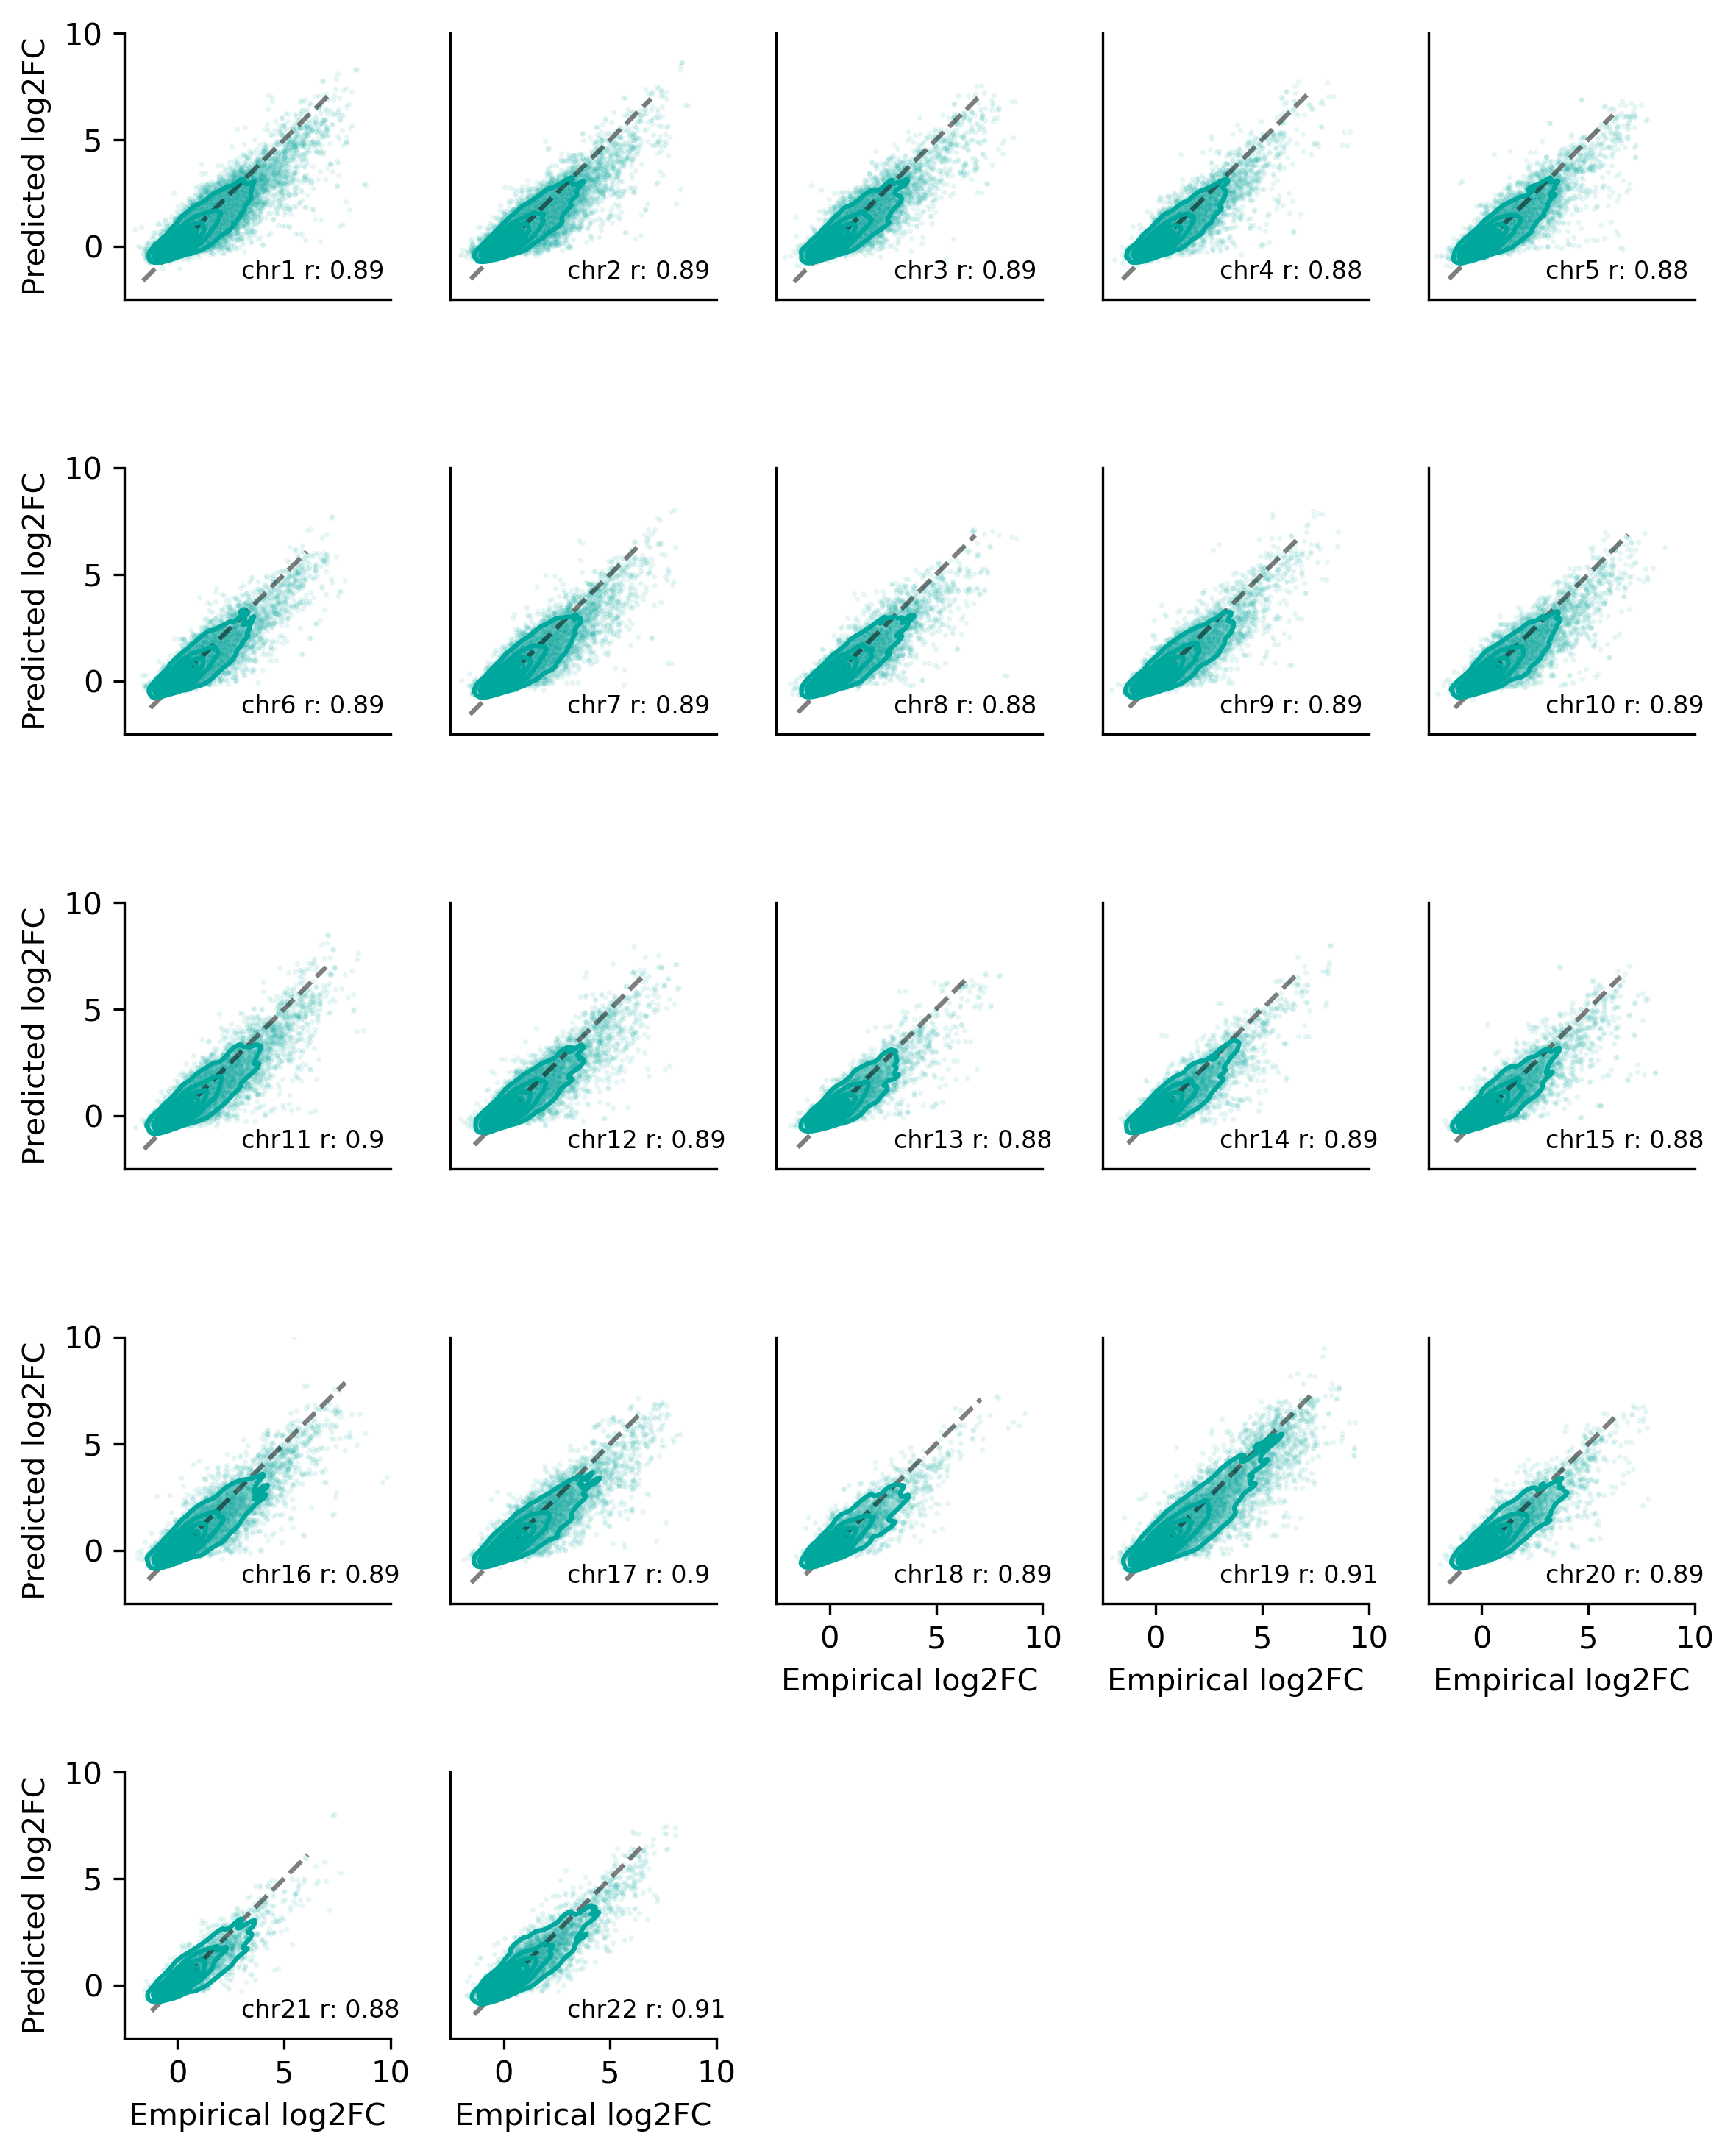

In [42]:
# k562
k562_chrom_correlations  = chrom_specific_scatters_grid(all_snps_with_controls, 
                                                   '#00A79D', 
                                                   'K562', 
                                                   '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/MPRA_Scatters/chrom_scatters/all_chrom_k562_activity_with_controls_grid.pdf')


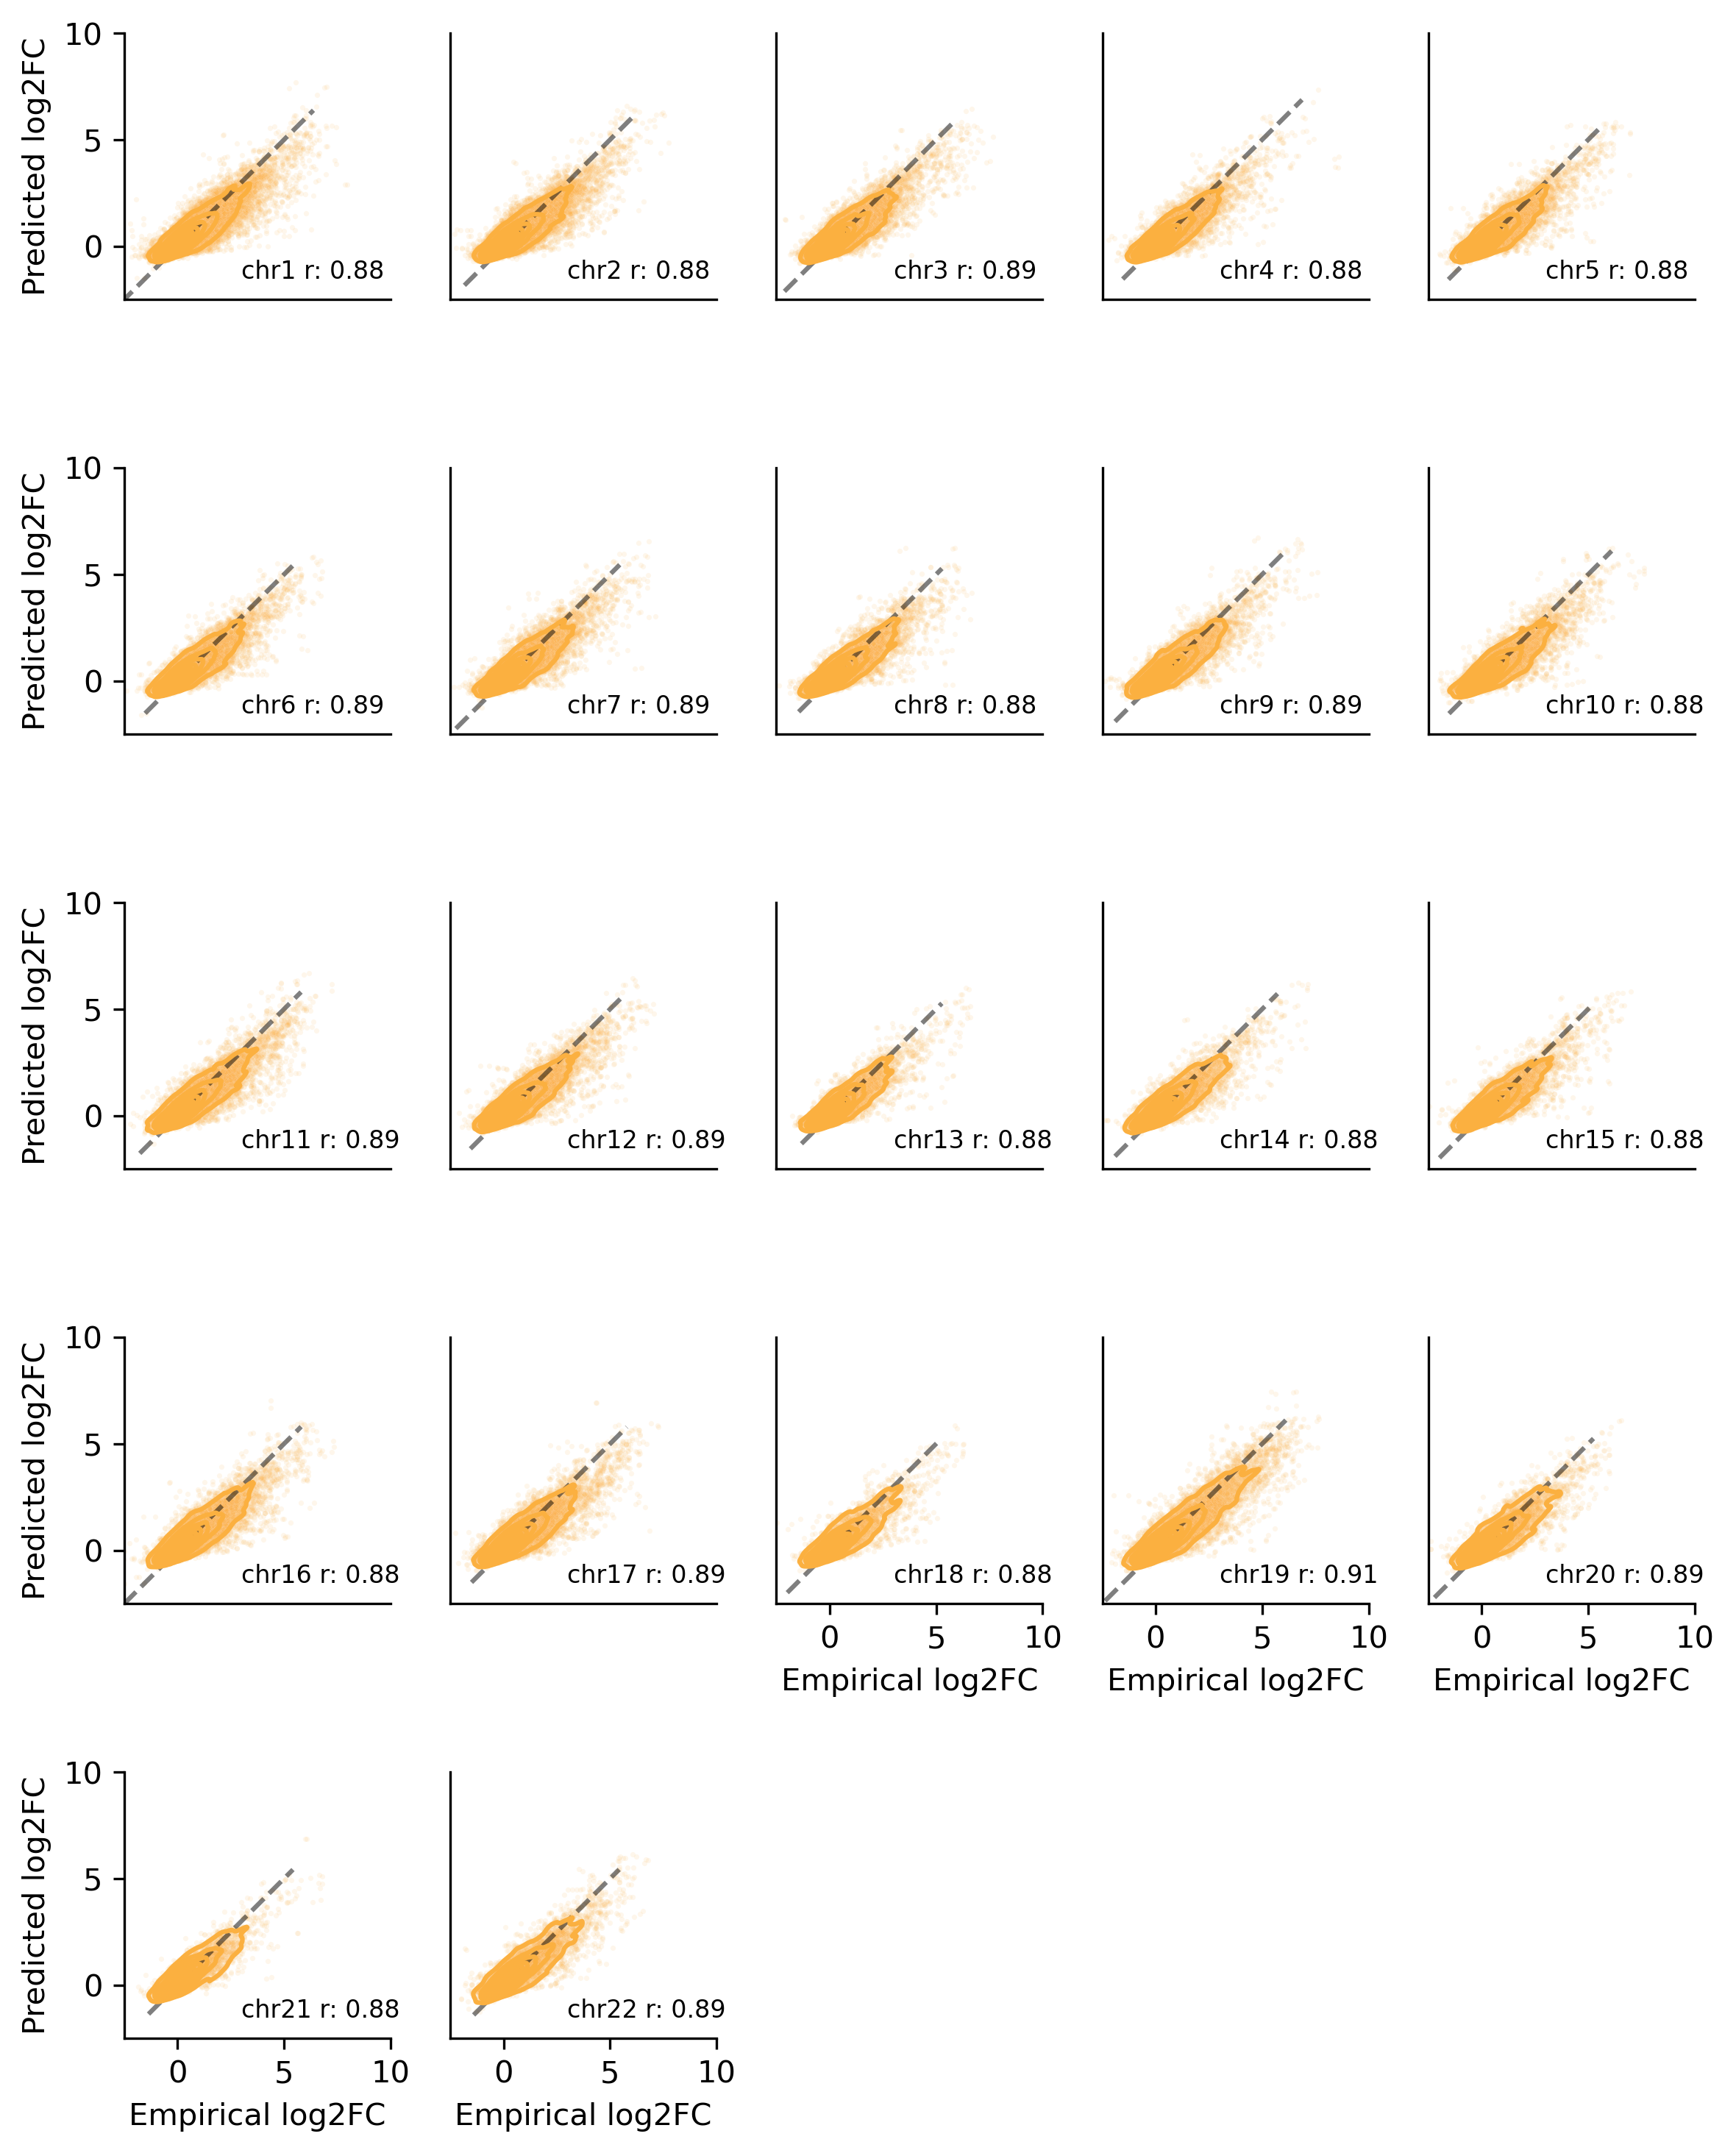

In [43]:
# hepg2
hepg2_chrom_correlations  = chrom_specific_scatters_grid(all_snps_with_controls, 
                                                         '#FBB040', 
                                                         'HEPG2', 
                                                         '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/MPRA_Scatters/chrom_scatters/all_chrom_hepg2_activity_with_controls_grid.pdf')


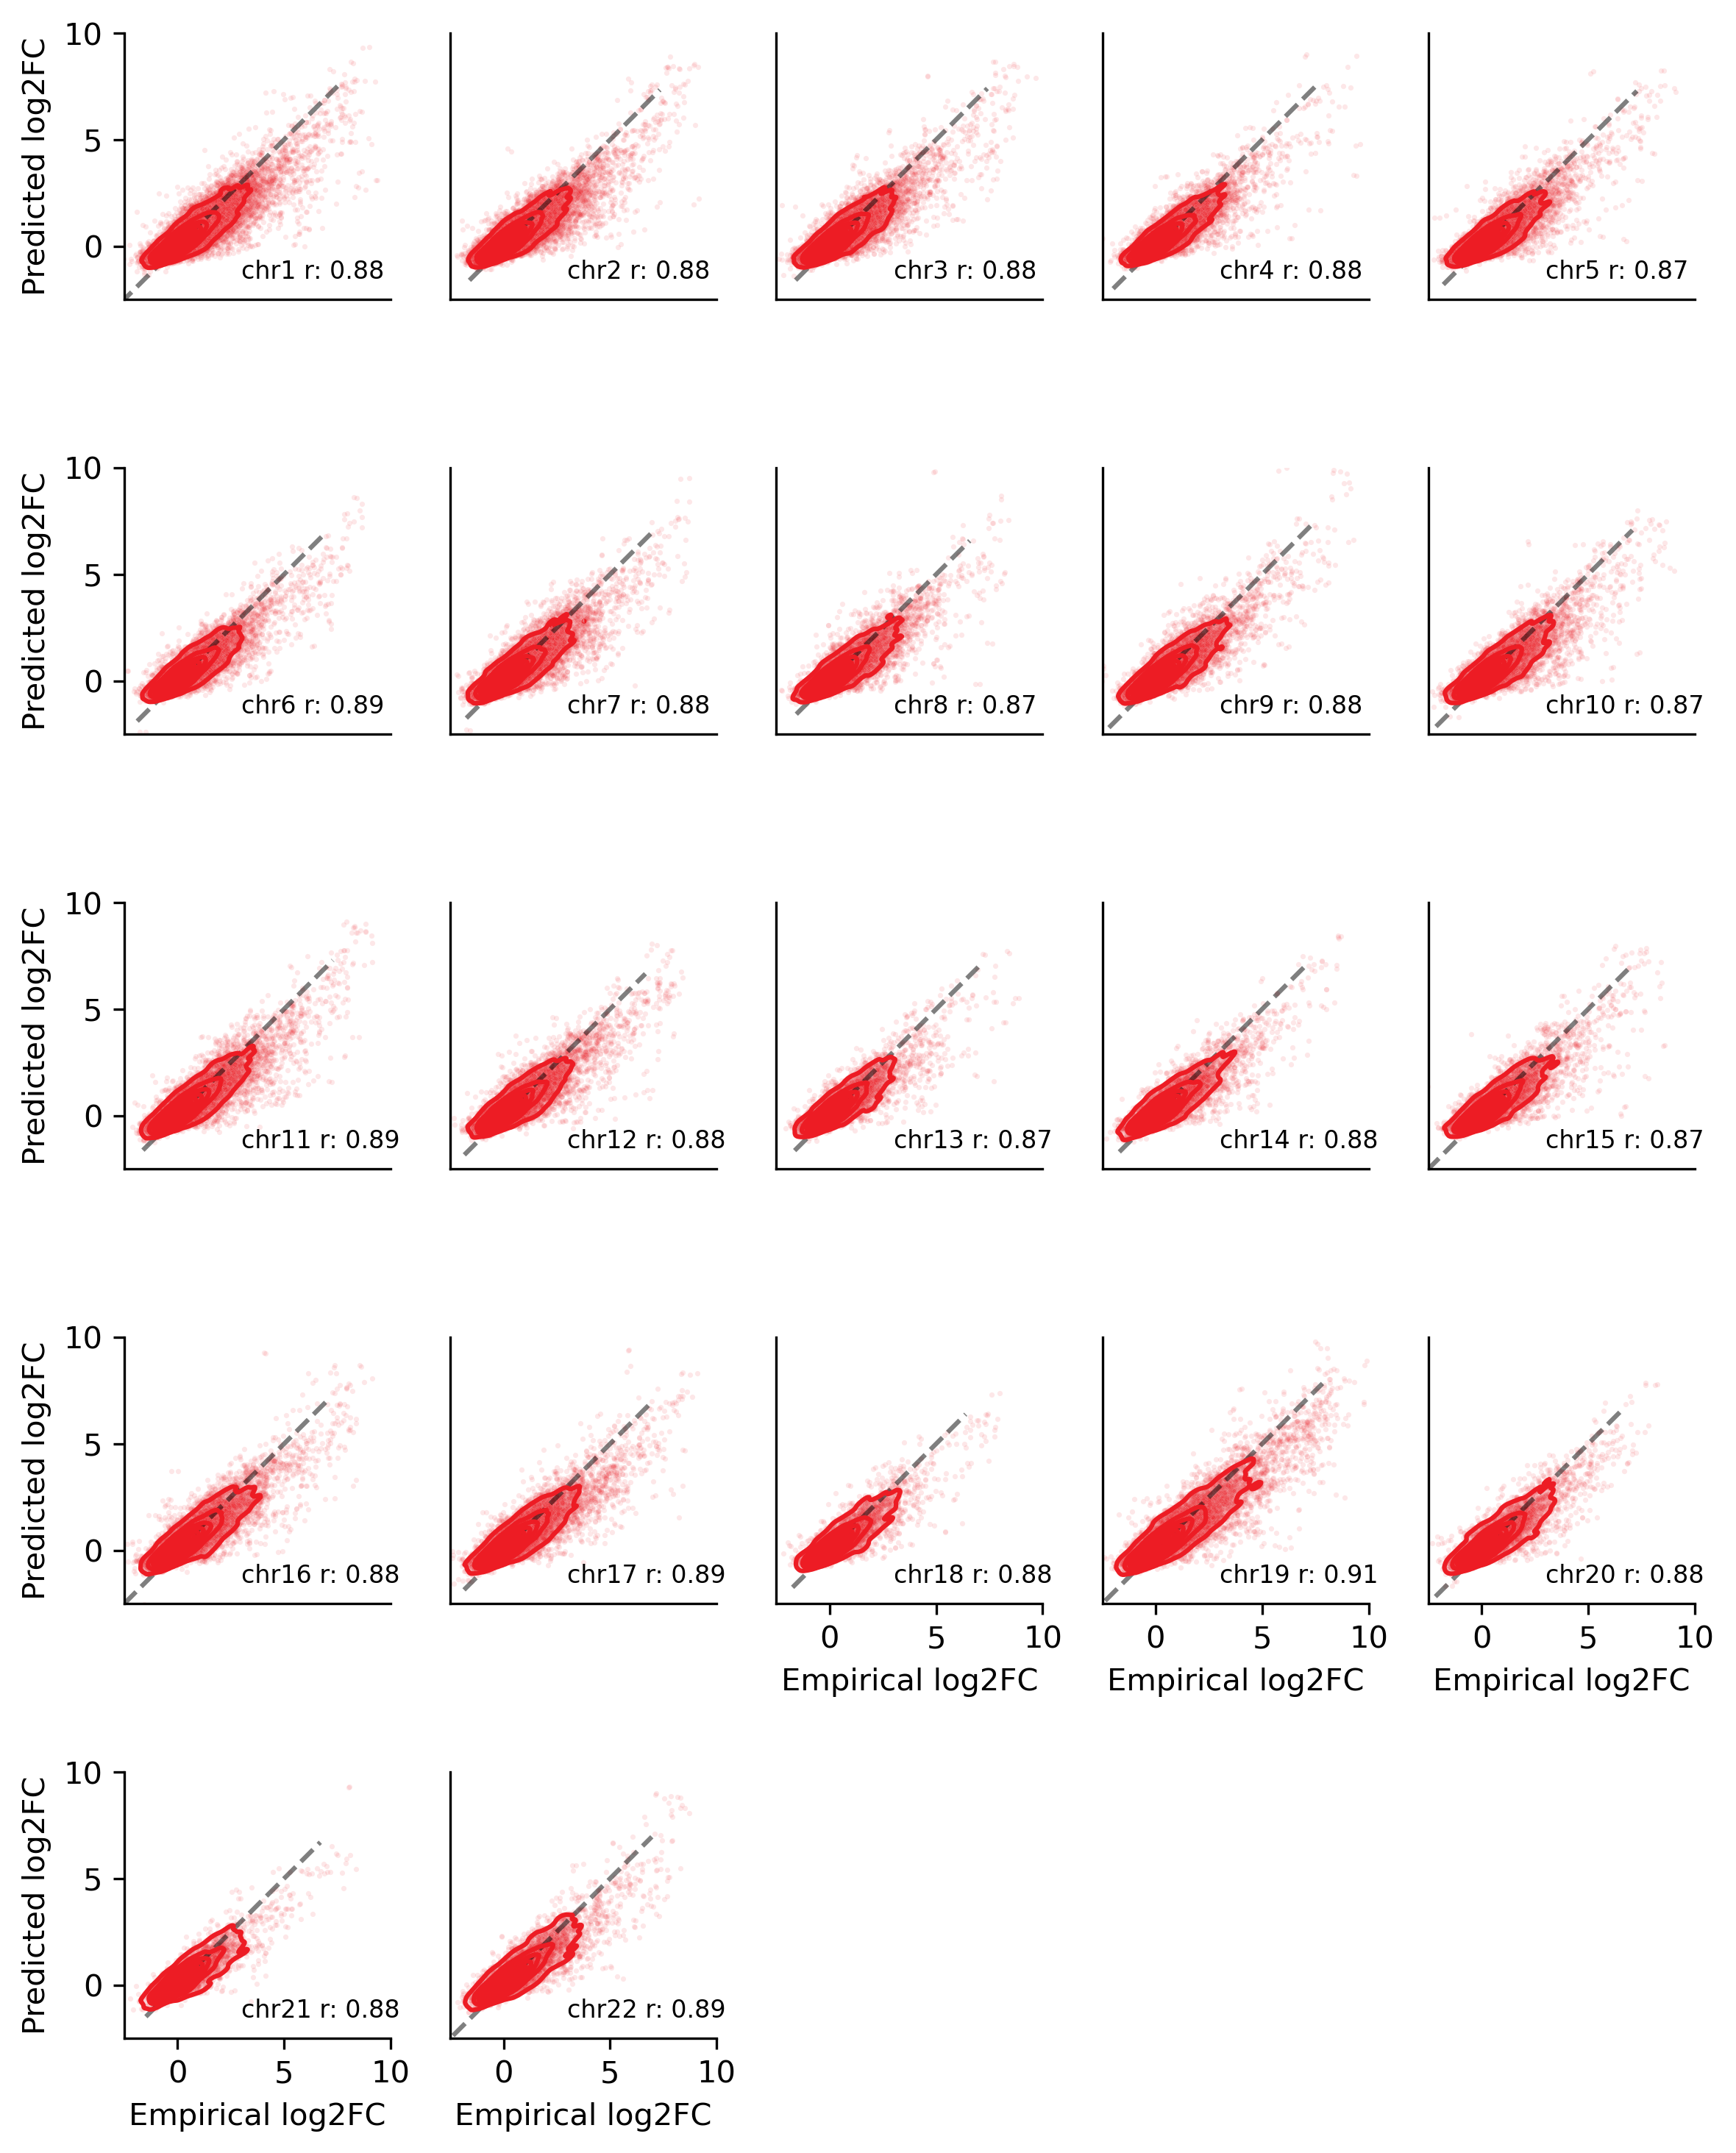

In [44]:
# sknsh
sknsh_chrom_correlations  = chrom_specific_scatters_grid(all_snps_with_controls, 
                                                   '#ED1C24', 
                                                   'SKNSH', 
                                                   '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/MPRA_Scatters/chrom_scatters/all_chrom_sknsh_activity_with_controls_grid.pdf')


In [46]:
# define function to plot scatters for activity and skew by chromosome
def chrom_specific_scatters_with_bar (merged_df, 
                      color, 
                      cell_type,
                      output_path,
                      k_corr_dict,
                      h_corr_dict,
                      s_corr_dict):
    chrom_corr_bar_df = pd.concat([pd.DataFrame({'chrom' : [i for i in k_corr_dict.keys()],
                                             'corr' : [k_corr_dict.get(i) for i in k_corr_dict.keys()],
                                             'cell_type' : ['K562' for i in range(len(k_corr_dict.keys()))]}),
                               pd.DataFrame({'chrom' : [i for i in h_corr_dict.keys()],
                                             'corr' : [h_corr_dict.get(i) for i in h_corr_dict.keys()],
                                             'cell_type' : ['HEPG2' for i in range(len(h_corr_dict.keys()))]}),
                               pd.DataFrame({'chrom' : [i for i in s_corr_dict.keys()],
                                             'corr' : [s_corr_dict.get(i) for i in s_corr_dict.keys()],
                                             'cell_type' : ['SKNSH' for i in range(len(s_corr_dict.keys()))]})])
    # make a palette to color the bars
    bar_palette = {'K562' : '#00A79D',
               'HEPG2' : '#FBB040',
               'SKNSH' : '#ED1C24'}
    # get cell type
    if cell_type == 'K562':
        cell_lower = 'k562'
    elif cell_type == 'HEPG2':
        cell_lower = 'hepg2'
    elif cell_type == 'SKNSH':
        cell_lower = 'sknsh'
    # define grid position variables
    row = 0
    col = 0
    # filter for cell type
    cell_df = merged_df[merged_df['cell_type'] == cell_type]
    # get list of chromosomes
    autosomes = cell_df['chromosome'].unique()
    correlation_dict = {}
    f = mpl.figure(figsize=(8,10),dpi=300)
    gs = f.add_gridspec(5,5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    for i in autosomes:
        # define x axis labels
        if row == 4:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 3:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 4:
            xlab = 'Empirical log2FC'
        elif row == 3 and col == 2:
            xlab = 'Empirical log2FC'
        else:
            xlab = ''
        # define y axis labels
        if col == 0:
            ylab = 'Predicted log2FC'
        else:
            ylab = ''
        # define ticks/labels
        if row == 4:
            xtick = [0,5,10]
        elif row == 3 and col == 3:
            xtick = [0,5,10]
        elif row == 3 and col == 4:
            xtick = [0,5,10]
        elif row == 3 and col == 2:
            xtick = [0,5,10]
        else:
            xtick = []
        if col == 0:
            ytick = [0,5,10]
        else:
            ytick = []
        chrom_df =cell_df[cell_df['chromosome'] == i]
        ref = chrom_df['A_log2FC'].tolist()
        alt = chrom_df['B_log2FC'].tolist()
        ref.extend(alt)
        # combine ref and alt preds for pearson r
        ref_pred = chrom_df[f'{cell_lower}_ref_pred_pos_100'].tolist()
        alt_pred = chrom_df[f'{cell_lower}_alt_pred_pos_100'].tolist()
        ref_pred.extend(alt_pred)
        # get pearson r
        pearson, pval = stats.pearsonr(x=ref, 
                                       y=ref_pred)
        round_pearson = round(pearson, 2)
        # plot KDE
        # make df for KDE
        # empirical data
        mpra_l2fc = chrom_df['A_log2FC'].tolist()
        mpra_l2fc.extend(chrom_df['B_log2FC'].tolist())
        # prediction data
        malinois_l2fc = chrom_df[f'{cell_lower}_ref_pred_pos_100'].tolist()
        malinois_l2fc.extend(chrom_df[f'{cell_lower}_alt_pred_pos_100'].tolist())
        kde_df = pd.DataFrame({'empirical_l2fc' : mpra_l2fc,
                               'malinois_l2fc' : malinois_l2fc})
        # plot correlation with KDE
        ax = f.add_subplot(gs[row,col])
        #ax.set(adjustable='box', aspect='equal')
        mpl.plot([(.8 * min(chrom_df['A_log2FC'])), (.8 * max(chrom_df['A_log2FC']))],
                 [(.8 * min(chrom_df['A_log2FC'])), (.8 * max(chrom_df['A_log2FC']))],
                 linestyle='dashed',
                 alpha=.5,
                 color='k')
        sns.kdeplot(data=kde_df, x='empirical_l2fc', y='malinois_l2fc',color=color)
        # plot correlation
        sns.scatterplot(data=kde_df,
                        x='empirical_l2fc',
                        y='malinois_l2fc',
                        legend=False,
                        color=color,
                        s=3,
                        alpha=.1,
                        rasterized=True) 
        mpl.xlim(-2.5, 10)
        mpl.ylim(-2.5, 10)
        mpl.xlabel(xlab)
        mpl.ylabel(ylab)
        mpl.xticks(ticks=xtick, labels=xtick)
        mpl.yticks(ticks=ytick, labels=ytick)
        mpl.annotate(xy=(3,-1.5), text=f'{i} r: {round_pearson}', fontsize=8)
        correlation_dict.update({i : pearson})
        col +=1
        if col == 5:
            col=0
            row+=1
    ax = f.add_subplot(gs[4,2:])
    sns.barplot(data=chrom_corr_bar_df,
            x='chrom',
            y='corr',
            hue='cell_type',
            palette=bar_palette)
    mpl.ylim(.8, 1)
    mpl.ylabel('')
    mpl.xlabel('')
    mpl.legend(loc='upper right', fontsize='x-small')
    mpl.xticks(rotation=90)
    sns.despine()
    mpl.tight_layout()
    #mpl.savefig(output_path)
    return correlation_dict

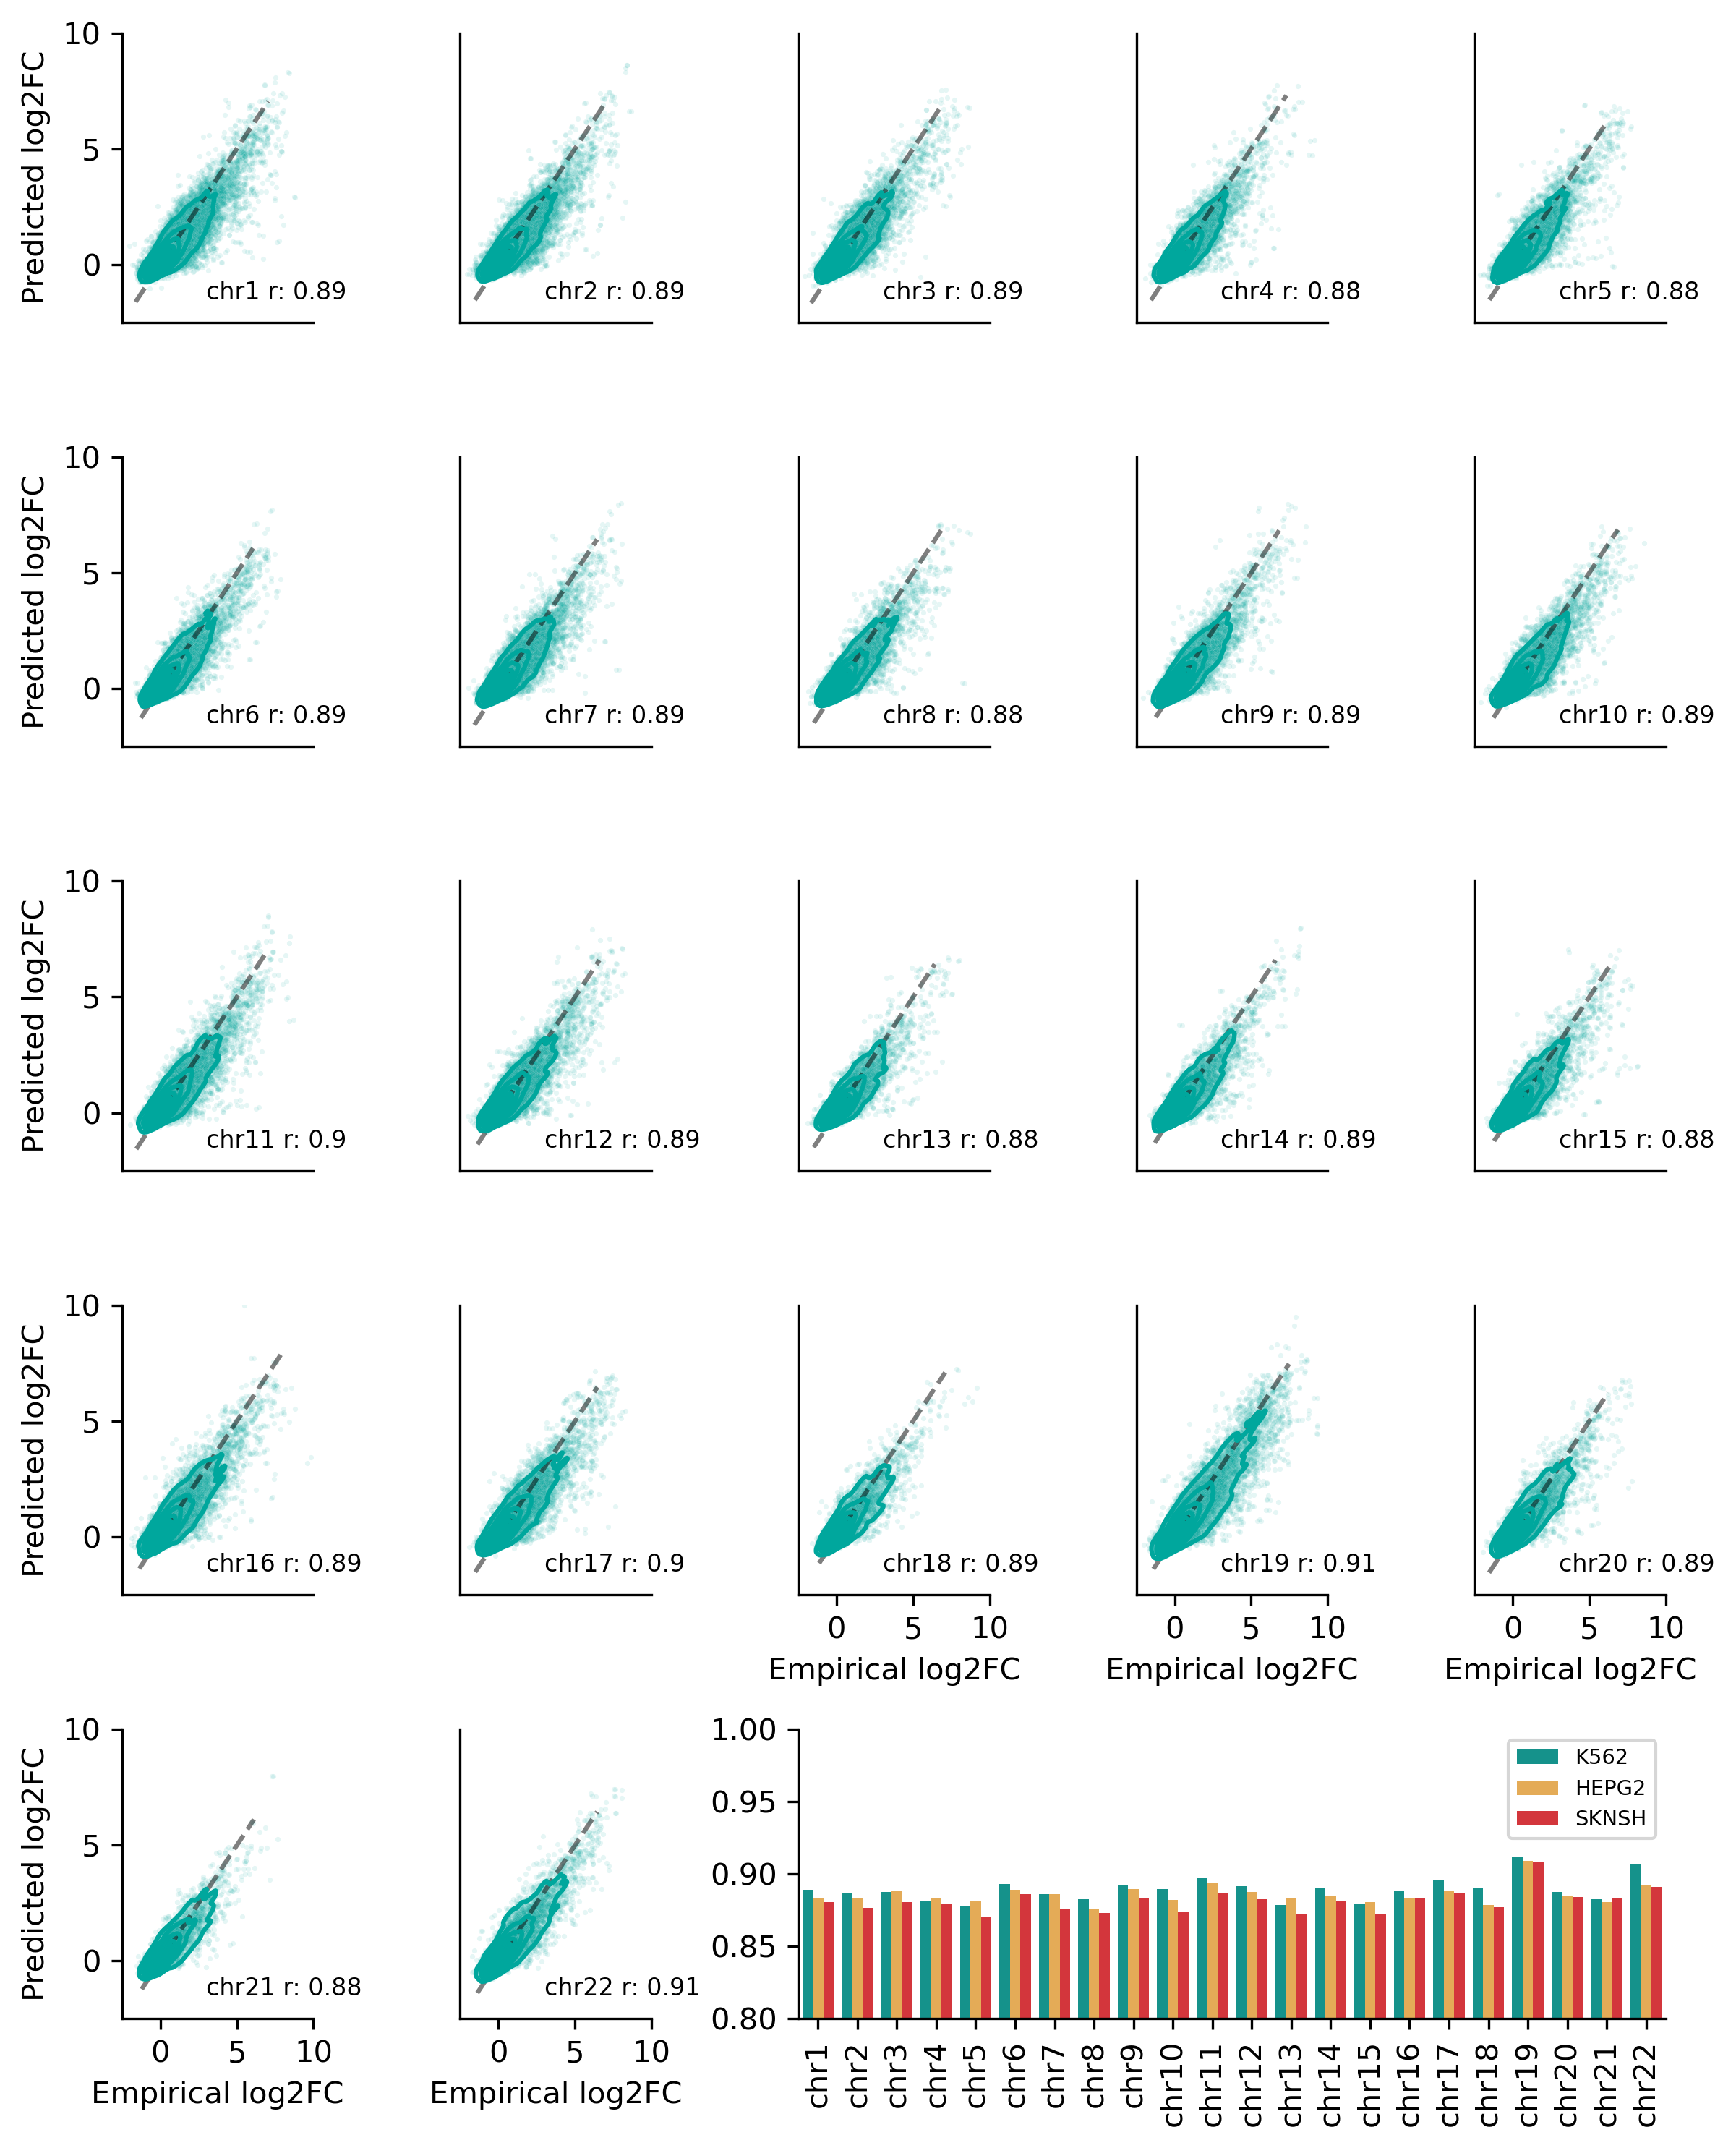

In [47]:
# plot chromosome specific correlations
# k562
k562_chrom_correlations = chrom_specific_scatters_with_bar(all_snps_with_controls, 
                                                   '#00A79D', 
                                                   'K562', 
                                                   '/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/MPRA_Scatters/chrom_scatters/all_chrom_k562_activity_with_controls_grid.pdf',
                                                   k562_chrom_correlations,
                                                   hepg2_chrom_correlations,
                                                   sknsh_chrom_correlations)

In [285]:
# save merged predictions to file
#all_snps_with_controls.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all_ukbb_gtex_preds_merge_with_controls.tsv',
#                              sep = '\t',
#                              index = False)